 Phishing Detection

In [2]:
import pandas as pd
import numpy as np
import joblib
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif, SelectFromModel, RFE
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from bhho_optimizer import BHHO, create_fitness_function

os.makedirs('models', exist_ok=True)
sns.set_theme(style="whitegrid")

def evaluate_model(name, X_train, X_test, y_train, y_test, feature_names=None):
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X_train, y_train)
    
    train_preds = rf.predict(X_train)
    test_preds = rf.predict(X_test)
    
    train_acc = accuracy_score(y_train, train_preds)
    test_acc = accuracy_score(y_test, test_preds)
    precision = precision_score(y_test, test_preds, average='macro', zero_division=0)
    recall = recall_score(y_test, test_preds, average='macro', zero_division=0)
    f1 = f1_score(y_test, test_preds, average='macro', zero_division=0)
    cm = confusion_matrix(y_test, test_preds)
    
    print(f"\n--- {name} ---")
    print(f"Features Used: {X_train.shape[1]}")
    print(f"Training Accuracy: {train_acc:.4f} | Testing Accuracy:  {test_acc:.4f}")
    print(f"Precision: {precision:.4f} | Recall: {recall:.4f} | F1-Score: {f1:.4f}")
    
    return {
        'model': rf,
        'test_acc': test_acc,
        'cm': cm,
        'features': feature_names
    }

def plot_advanced_results(dataset_name, results_dict, bhho_history):
    fig = plt.figure(figsize=(20, 15))
    fig.suptitle(f'Advanced Analysis: {dataset_name}', fontsize=24, fontweight='bold')

    # 1. Convergence Curve
    ax1 = plt.subplot(2, 2, 1)
    ax1.plot(range(1, len(bhho_history) + 1), bhho_history, marker='o', color='#8b5cf6', linewidth=2)
    ax1.set_title('BHHO Convergence Curve (Fitness over Iterations)', fontsize=14)
    ax1.set_xlabel('Iteration')
    ax1.set_ylabel('Fitness (Error + Feature Penalty)')
    
    # 2. Comparative Accuracy
    ax2 = plt.subplot(2, 2, 2)
    names = list(results_dict.keys())
    accs = [res['test_acc'] * 100 for res in results_dict.values()]
    colors = ['#94a3b8', '#3b82f6', '#3b82f6', '#f59e0b', '#ec4899', '#10b981']
    colors = colors[:len(accs)] # Ensure we don't pass too many colors
    bars = ax2.bar(names, accs, color=colors)
    ax2.set_title('Testing Accuracy Comparison', fontsize=14)
    ax2.set_ylabel('Accuracy (%)')
    ax2.set_ylim(min(accs) - 2 if min(accs) > 2 else 0, 100)
    for bar in bars:
        yval = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f'{yval:.2f}%', ha='center', va='bottom', fontweight='bold')

    # 3. Confusion Matrix for BHHO
    ax3 = plt.subplot(2, 2, 3)
    bhho_cm = results_dict['Proposed (BHHO)']['cm']
    sns.heatmap(bhho_cm, annot=True, fmt='d', cmap='Blues', ax=ax3, cbar=False,
                xticklabels=['Safe', 'Phishing'], yticklabels=['Safe', 'Phishing'])
    ax3.set_title('BHHO Confusion Matrix', fontsize=14)
    ax3.set_xlabel('Predicted Label')
    ax3.set_ylabel('True Label')

    # 4. Feature Importance for BHHO
    ax4 = plt.subplot(2, 2, 4)
    bhho_rf = results_dict['Proposed (BHHO)']['model']
    bhho_feats = results_dict['Proposed (BHHO)']['features']
    importances = bhho_rf.feature_importances_
    
    # Get top 15 features
    indices = np.argsort(importances)[-15:]
    top_feats = [bhho_feats[i] for i in indices]
    top_imps = importances[indices]
    
    ax4.barh(range(len(indices)), top_imps, align='center', color='#ec4899')
    ax4.set_yticks(range(len(indices)))
    ax4.set_yticklabels(top_feats)
    ax4.set_title('Top 15 Most Important Features (BHHO)', fontsize=14)
    ax4.set_xlabel('Random Forest Importance Weight')
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


SMS Dataset


1. Dataset & Preprocessing...
2. Data Splitting...
3. Feature Extraction (TF-IDF)...
4. Feature Selection...
Iteration 1/25 - Best Fitness: 0.0633 - Features Selected: 263/500
Iteration 2/25 - Best Fitness: 0.0493 - Features Selected: 376/500
Iteration 3/25 - Best Fitness: 0.0435 - Features Selected: 434/500
Iteration 4/25 - Best Fitness: 0.0435 - Features Selected: 434/500
Iteration 5/25 - Best Fitness: 0.0415 - Features Selected: 453/500
Iteration 6/25 - Best Fitness: 0.0415 - Features Selected: 453/500
Iteration 7/25 - Best Fitness: 0.0400 - Features Selected: 454/500
Iteration 8/25 - Best Fitness: 0.0400 - Features Selected: 454/500
Iteration 9/25 - Best Fitness: 0.0400 - Features Selected: 454/500
Iteration 10/25 - Best Fitness: 0.0400 - Features Selected: 454/500
Iteration 11/25 - Best Fitness: 0.0400 - Features Selected: 454/500
Iteration 12/25 - Best Fitness: 0.0400 - Features Selected: 454/500
Iteration 13/25 - Best Fitness: 0.0400 - Features Selected: 454/500
Iteration 14/25 

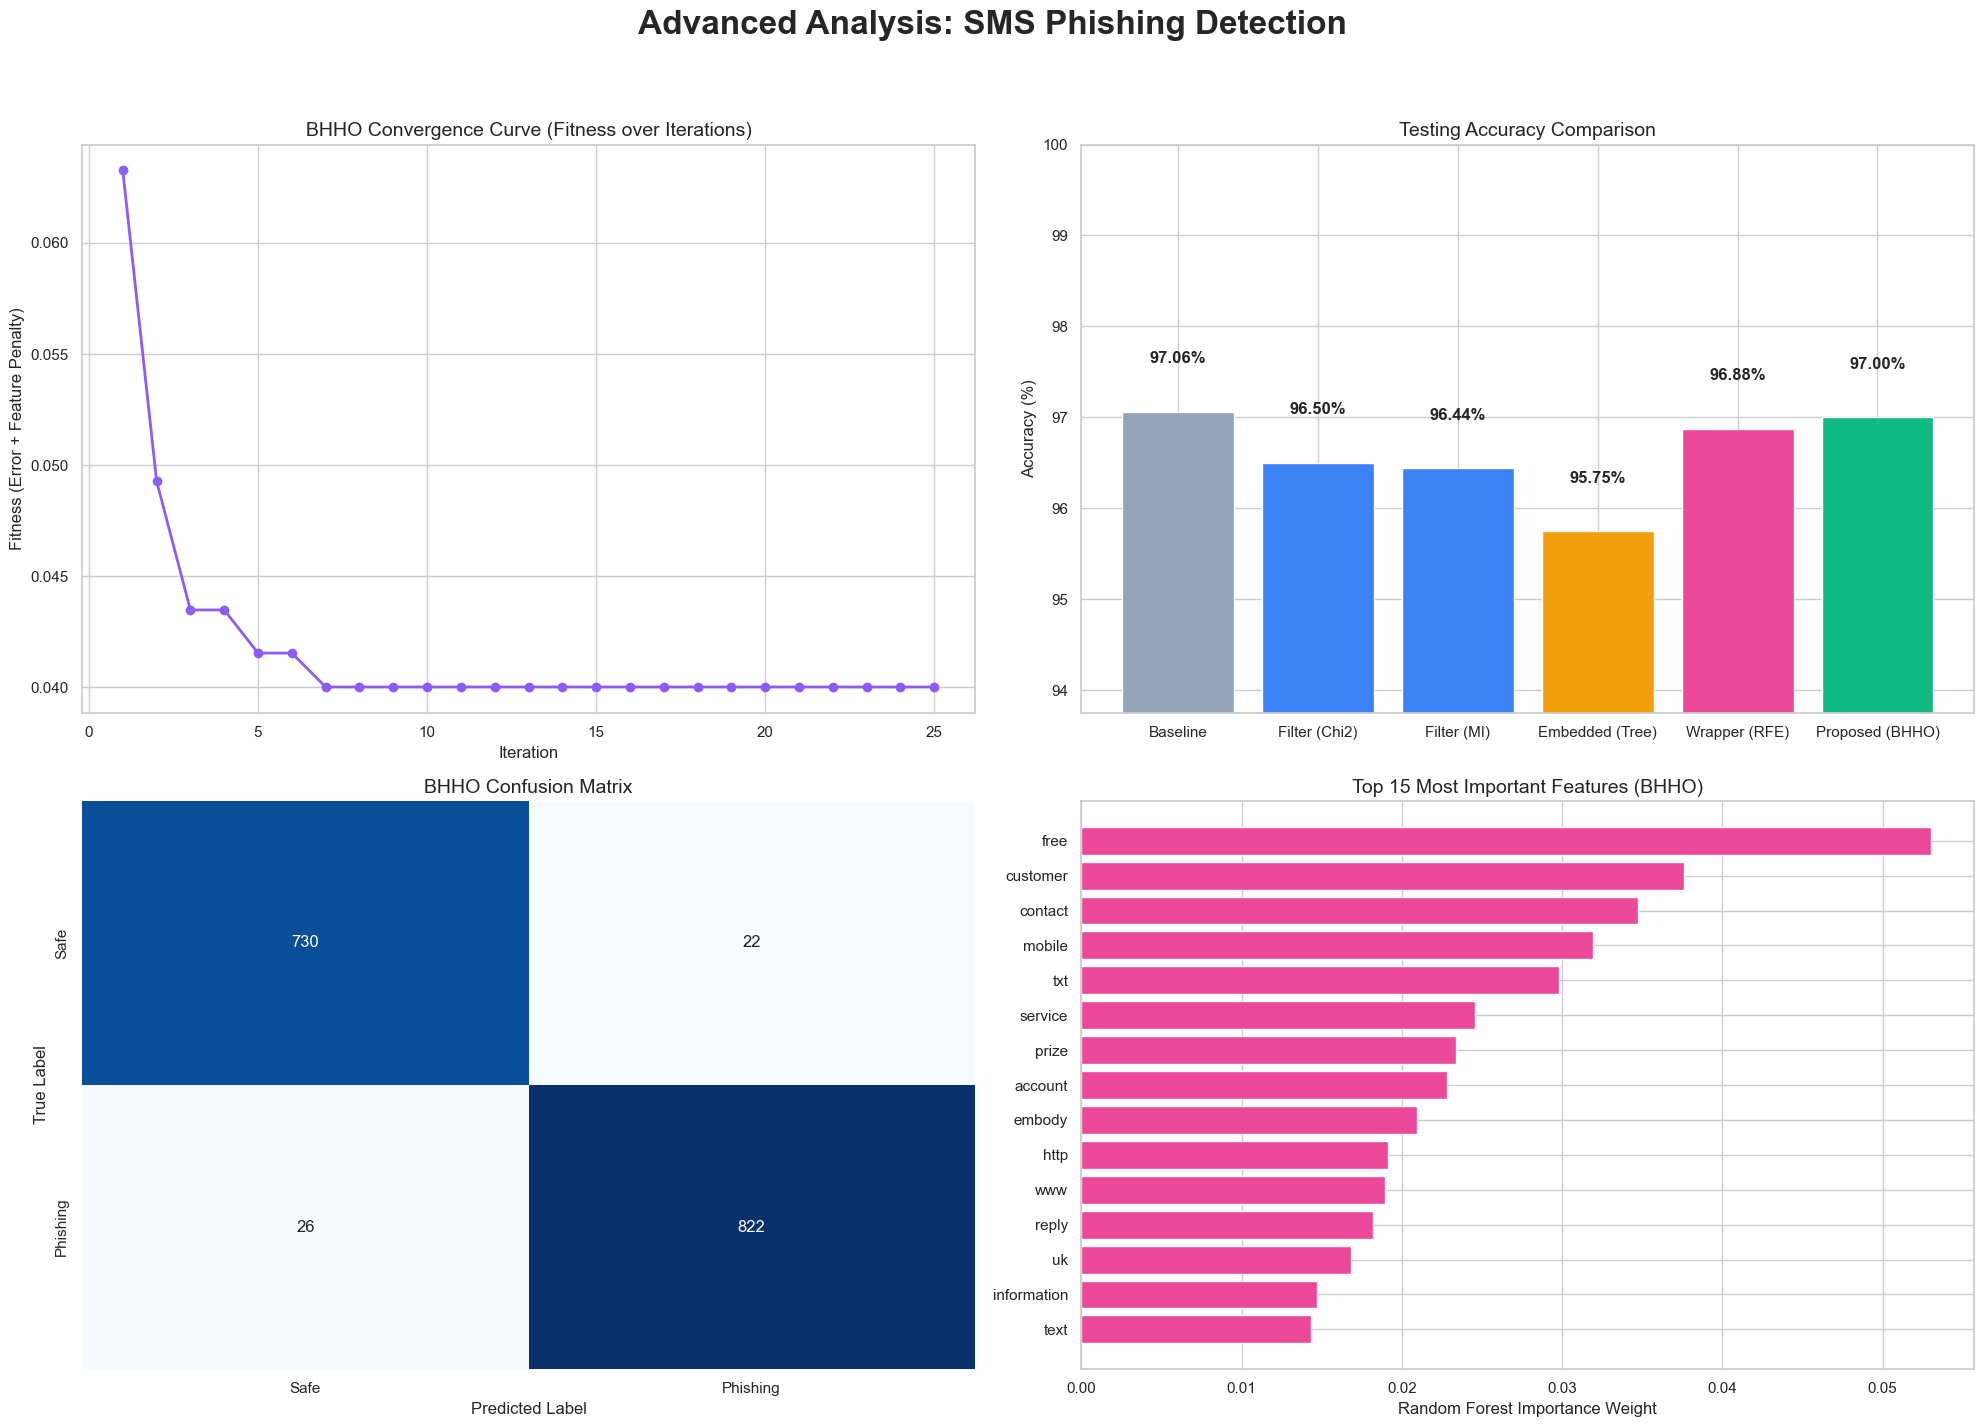

['models/sms_model.pkl']

In [3]:
print("1. Dataset & Preprocessing...")
sms_df1 = pd.read_csv('Dataset_5971 SMS Kaggle.csv').dropna(subset=['TEXT', 'LABEL'])
sms_df1 = sms_df1.rename(columns={'TEXT': 'text', 'LABEL': 'label'})
sms_df2 = pd.read_csv('SMS_Dataset_10191.csv').dropna(subset=['TEXT', 'LABEL'])
sms_df2 = sms_df2.rename(columns={'TEXT': 'text', 'LABEL': 'label'})
sms_df3 = pd.read_csv('SMS_composite_test.csv', on_bad_lines='skip').dropna(subset=['text', 'label'])
sms_df = pd.concat([sms_df1, sms_df2, sms_df3], ignore_index=True)
sample_size = min(8000, len(sms_df))
sms_df = sms_df.sample(n=sample_size, random_state=42)
X_sms_text = sms_df['text']
y_sms = sms_df['label'].apply(lambda x: 0 if str(x).strip().lower() in ['ham', '0', '0.0'] else 1)

print("2. Data Splitting...")
X_train_text, X_test_text, y_train, y_test = train_test_split(X_sms_text, y_sms, test_size=0.2, random_state=42)

print("3. Feature Extraction (TF-IDF)...")
sms_vectorizer = TfidfVectorizer(max_features=500, stop_words='english')
X_train_tfidf = sms_vectorizer.fit_transform(X_train_text).toarray()
X_test_tfidf = sms_vectorizer.transform(X_test_text).toarray()
all_feature_names = sms_vectorizer.get_feature_names_out()

print("4. Feature Selection...")
chi2_selector = SelectKBest(chi2, k=250)
X_train_chi2 = chi2_selector.fit_transform(X_train_tfidf, y_train)
X_test_chi2 = chi2_selector.transform(X_test_tfidf)
chi2_features = all_feature_names[chi2_selector.get_support()]

mi_selector = SelectKBest(mutual_info_classif, k=250)
X_train_mi = mi_selector.fit_transform(X_train_tfidf, y_train)
X_test_mi = mi_selector.transform(X_test_tfidf)
mi_features = all_feature_names[mi_selector.get_support()]

embed_selector = SelectFromModel(DecisionTreeClassifier(random_state=42), max_features=250)
X_train_embed = embed_selector.fit_transform(X_train_tfidf, y_train)
X_test_embed = embed_selector.transform(X_test_tfidf)
embed_features = all_feature_names[embed_selector.get_support()]

wrapper_selector = RFE(estimator=DecisionTreeClassifier(random_state=42), n_features_to_select=250, step=50)
X_train_wrapper = wrapper_selector.fit_transform(X_train_tfidf, y_train)
X_test_wrapper = wrapper_selector.transform(X_test_tfidf)
wrapper_features = all_feature_names[wrapper_selector.get_support()]

fitness_func = create_fitness_function(X_train_tfidf, y_train)
optimizer = BHHO(fitness_func, num_agents=20, max_iter=25, dim=X_train_tfidf.shape[1])
bhho_mask, history = optimizer.optimize()
X_train_bhho = X_train_tfidf[:, np.where(bhho_mask == 1)[0]]
X_test_bhho = X_test_tfidf[:, np.where(bhho_mask == 1)[0]]
bhho_features = all_feature_names[np.where(bhho_mask == 1)[0]]

print("5. Performance Measurement & Plotting...")
results = {}
results['Baseline'] = evaluate_model("Baseline (All Features)", X_train_tfidf, X_test_tfidf, y_train, y_test)
results['Filter (Chi2)'] = evaluate_model("Traditional (Chi-Square)", X_train_chi2, X_test_chi2, y_train, y_test, chi2_features)
results['Filter (MI)'] = evaluate_model("Traditional (Mutual Info)", X_train_mi, X_test_mi, y_train, y_test, mi_features)
results['Embedded (Tree)'] = evaluate_model("Embedded (Decision Tree)", X_train_embed, X_test_embed, y_train, y_test, embed_features)
results['Wrapper (RFE)'] = evaluate_model("Traditional Wrapper (RFE)", X_train_wrapper, X_test_wrapper, y_train, y_test, wrapper_features)
results['Proposed (BHHO)'] = evaluate_model("Proposed (BHHO)", X_train_bhho, X_test_bhho, y_train, y_test, bhho_features)

plot_advanced_results("SMS Phishing Detection", results, history)

# Save for Web App
joblib.dump(sms_vectorizer, 'models/sms_vectorizer.pkl')
joblib.dump(bhho_mask, 'models/sms_feature_mask.pkl')
joblib.dump(results['Proposed (BHHO)']['model'], 'models/sms_model.pkl')


 Email Dataset


1. Dataset & Preprocessing...
2. Data Splitting...
3. Feature Extraction (TF-IDF)...
4. Feature Selection...
Iteration 1/25 - Best Fitness: 0.0646 - Features Selected: 258/500
Iteration 2/25 - Best Fitness: 0.0646 - Features Selected: 258/500
Iteration 3/25 - Best Fitness: 0.0646 - Features Selected: 258/500
Iteration 4/25 - Best Fitness: 0.0607 - Features Selected: 310/500
Iteration 5/25 - Best Fitness: 0.0607 - Features Selected: 310/500
Iteration 6/25 - Best Fitness: 0.0557 - Features Selected: 308/500
Iteration 7/25 - Best Fitness: 0.0557 - Features Selected: 308/500
Iteration 8/25 - Best Fitness: 0.0557 - Features Selected: 308/500
Iteration 9/25 - Best Fitness: 0.0547 - Features Selected: 382/500
Iteration 10/25 - Best Fitness: 0.0547 - Features Selected: 382/500
Iteration 11/25 - Best Fitness: 0.0547 - Features Selected: 382/500
Iteration 12/25 - Best Fitness: 0.0547 - Features Selected: 382/500
Iteration 13/25 - Best Fitness: 0.0547 - Features Selected: 382/500
Iteration 14/25 

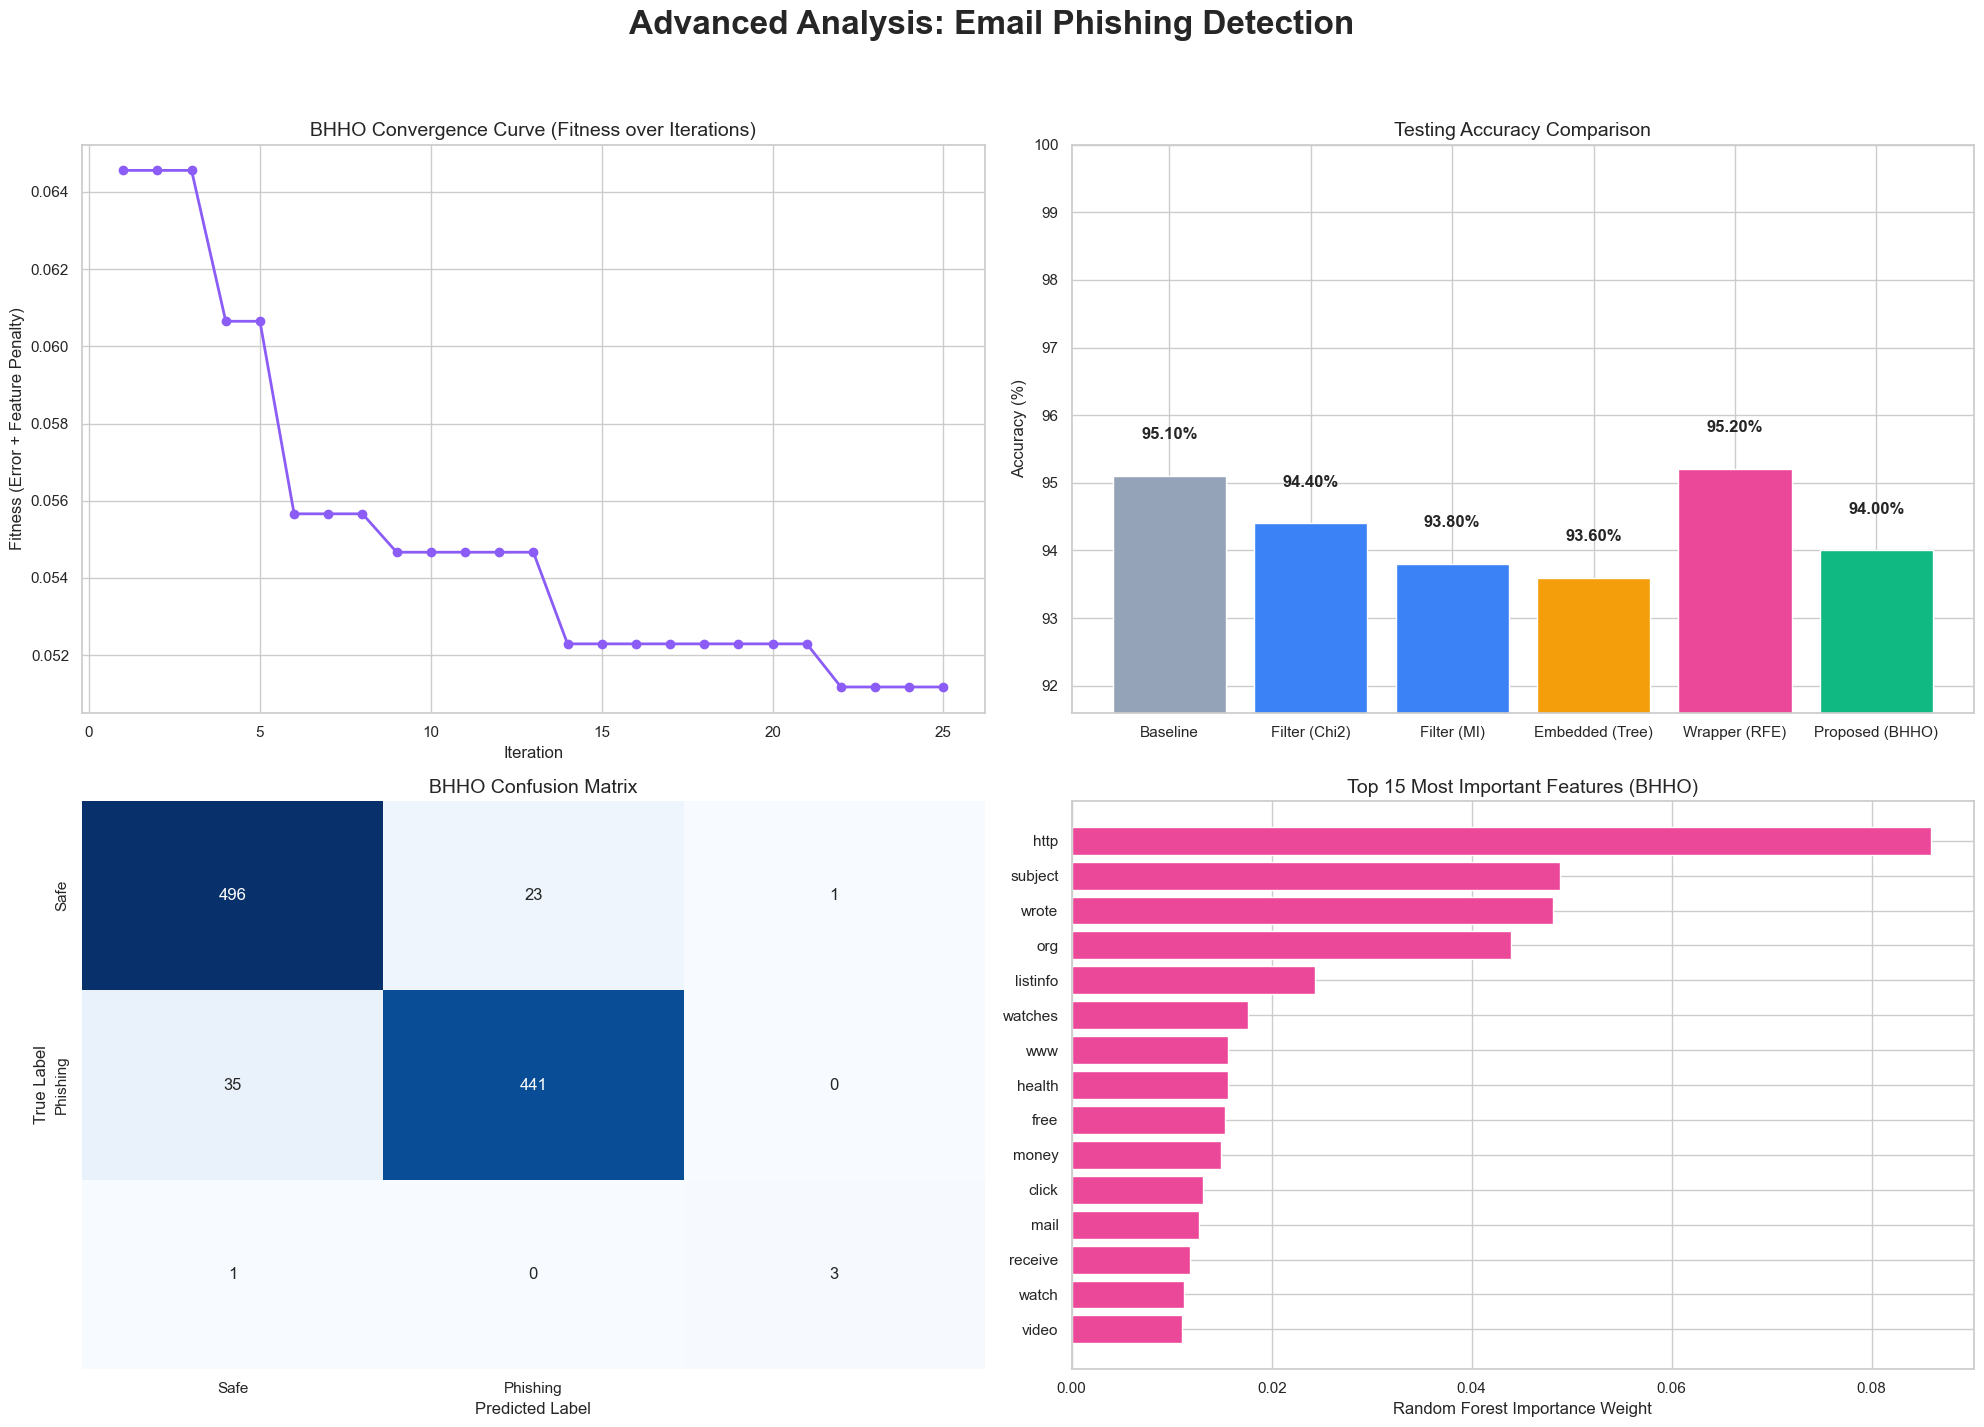

['models/email_model.pkl']

In [3]:
print("1. Dataset & Preprocessing...")
email_df1 = pd.read_csv('AVN_Basic.csv', on_bad_lines='skip').dropna(subset=['body', 'label'])
email_df2 = pd.read_csv('AVN_Corpus.csv', on_bad_lines='skip').dropna(subset=['body', 'label'])
email_df = pd.concat([email_df1, email_df2], ignore_index=True)
email_df['text'] = email_df['subject'].fillna('') + " " + email_df['body']

sample_size = min(5000, len(email_df))
email_df = email_df.sample(n=sample_size, random_state=42)
X_email_text = email_df['text']
y_email = email_df['label']

print("2. Data Splitting...")
X_train_text, X_test_text, y_train, y_test = train_test_split(X_email_text, y_email, test_size=0.2, random_state=42)

print("3. Feature Extraction (TF-IDF)...")
email_vectorizer = TfidfVectorizer(max_features=500, stop_words='english')
X_train_tfidf = email_vectorizer.fit_transform(X_train_text).toarray()
X_test_tfidf = email_vectorizer.transform(X_test_text).toarray()
all_feature_names = email_vectorizer.get_feature_names_out()

print("4. Feature Selection...")
chi2_selector = SelectKBest(chi2, k=250)
X_train_chi2 = chi2_selector.fit_transform(X_train_tfidf, y_train)
X_test_chi2 = chi2_selector.transform(X_test_tfidf)
chi2_features = all_feature_names[chi2_selector.get_support()]

mi_selector = SelectKBest(mutual_info_classif, k=250)
X_train_mi = mi_selector.fit_transform(X_train_tfidf, y_train)
X_test_mi = mi_selector.transform(X_test_tfidf)
mi_features = all_feature_names[mi_selector.get_support()]

embed_selector = SelectFromModel(DecisionTreeClassifier(random_state=42), max_features=250)
X_train_embed = embed_selector.fit_transform(X_train_tfidf, y_train)
X_test_embed = embed_selector.transform(X_test_tfidf)
embed_features = all_feature_names[embed_selector.get_support()]

wrapper_selector = RFE(estimator=DecisionTreeClassifier(random_state=42), n_features_to_select=250, step=50)
X_train_wrapper = wrapper_selector.fit_transform(X_train_tfidf, y_train)
X_test_wrapper = wrapper_selector.transform(X_test_tfidf)
wrapper_features = all_feature_names[wrapper_selector.get_support()]

fitness_func = create_fitness_function(X_train_tfidf, y_train)
optimizer = BHHO(fitness_func, num_agents=20, max_iter=25, dim=X_train_tfidf.shape[1])
bhho_mask, history = optimizer.optimize()
X_train_bhho = X_train_tfidf[:, np.where(bhho_mask == 1)[0]]
X_test_bhho = X_test_tfidf[:, np.where(bhho_mask == 1)[0]]
bhho_features = all_feature_names[np.where(bhho_mask == 1)[0]]

print("5. Performance Measurement & Plotting...")
results = {}
results['Baseline'] = evaluate_model("Baseline (All Features)", X_train_tfidf, X_test_tfidf, y_train, y_test)
results['Filter (Chi2)'] = evaluate_model("Traditional (Chi-Square)", X_train_chi2, X_test_chi2, y_train, y_test, chi2_features)
results['Filter (MI)'] = evaluate_model("Traditional (Mutual Info)", X_train_mi, X_test_mi, y_train, y_test, mi_features)
results['Embedded (Tree)'] = evaluate_model("Embedded (Decision Tree)", X_train_embed, X_test_embed, y_train, y_test, embed_features)
results['Wrapper (RFE)'] = evaluate_model("Traditional Wrapper (RFE)", X_train_wrapper, X_test_wrapper, y_train, y_test, wrapper_features)
results['Proposed (BHHO)'] = evaluate_model("Proposed (BHHO)", X_train_bhho, X_test_bhho, y_train, y_test, bhho_features)

plot_advanced_results("Email Phishing Detection", results, history)

# Save for Web App
joblib.dump(email_vectorizer, 'models/email_vectorizer.pkl')
joblib.dump(bhho_mask, 'models/email_feature_mask.pkl')
joblib.dump(results['Proposed (BHHO)']['model'], 'models/email_model.pkl')


URL Dataset


1. Dataset & Preprocessing...
2. Data Splitting...
3. Feature Extraction (TF-IDF)...
4. Feature Selection...
Iteration 1/25 - Best Fitness: 0.0495 - Features Selected: 245/500
Iteration 2/25 - Best Fitness: 0.0495 - Features Selected: 245/500
Iteration 3/25 - Best Fitness: 0.0467 - Features Selected: 356/500
Iteration 4/25 - Best Fitness: 0.0467 - Features Selected: 356/500
Iteration 5/25 - Best Fitness: 0.0463 - Features Selected: 334/500
Iteration 6/25 - Best Fitness: 0.0463 - Features Selected: 334/500
Iteration 7/25 - Best Fitness: 0.0463 - Features Selected: 334/500
Iteration 8/25 - Best Fitness: 0.0463 - Features Selected: 334/500
Iteration 9/25 - Best Fitness: 0.0463 - Features Selected: 334/500
Iteration 10/25 - Best Fitness: 0.0452 - Features Selected: 340/500
Iteration 11/25 - Best Fitness: 0.0452 - Features Selected: 340/500
Iteration 12/25 - Best Fitness: 0.0452 - Features Selected: 340/500
Iteration 13/25 - Best Fitness: 0.0452 - Features Selected: 340/500
Iteration 14/25 

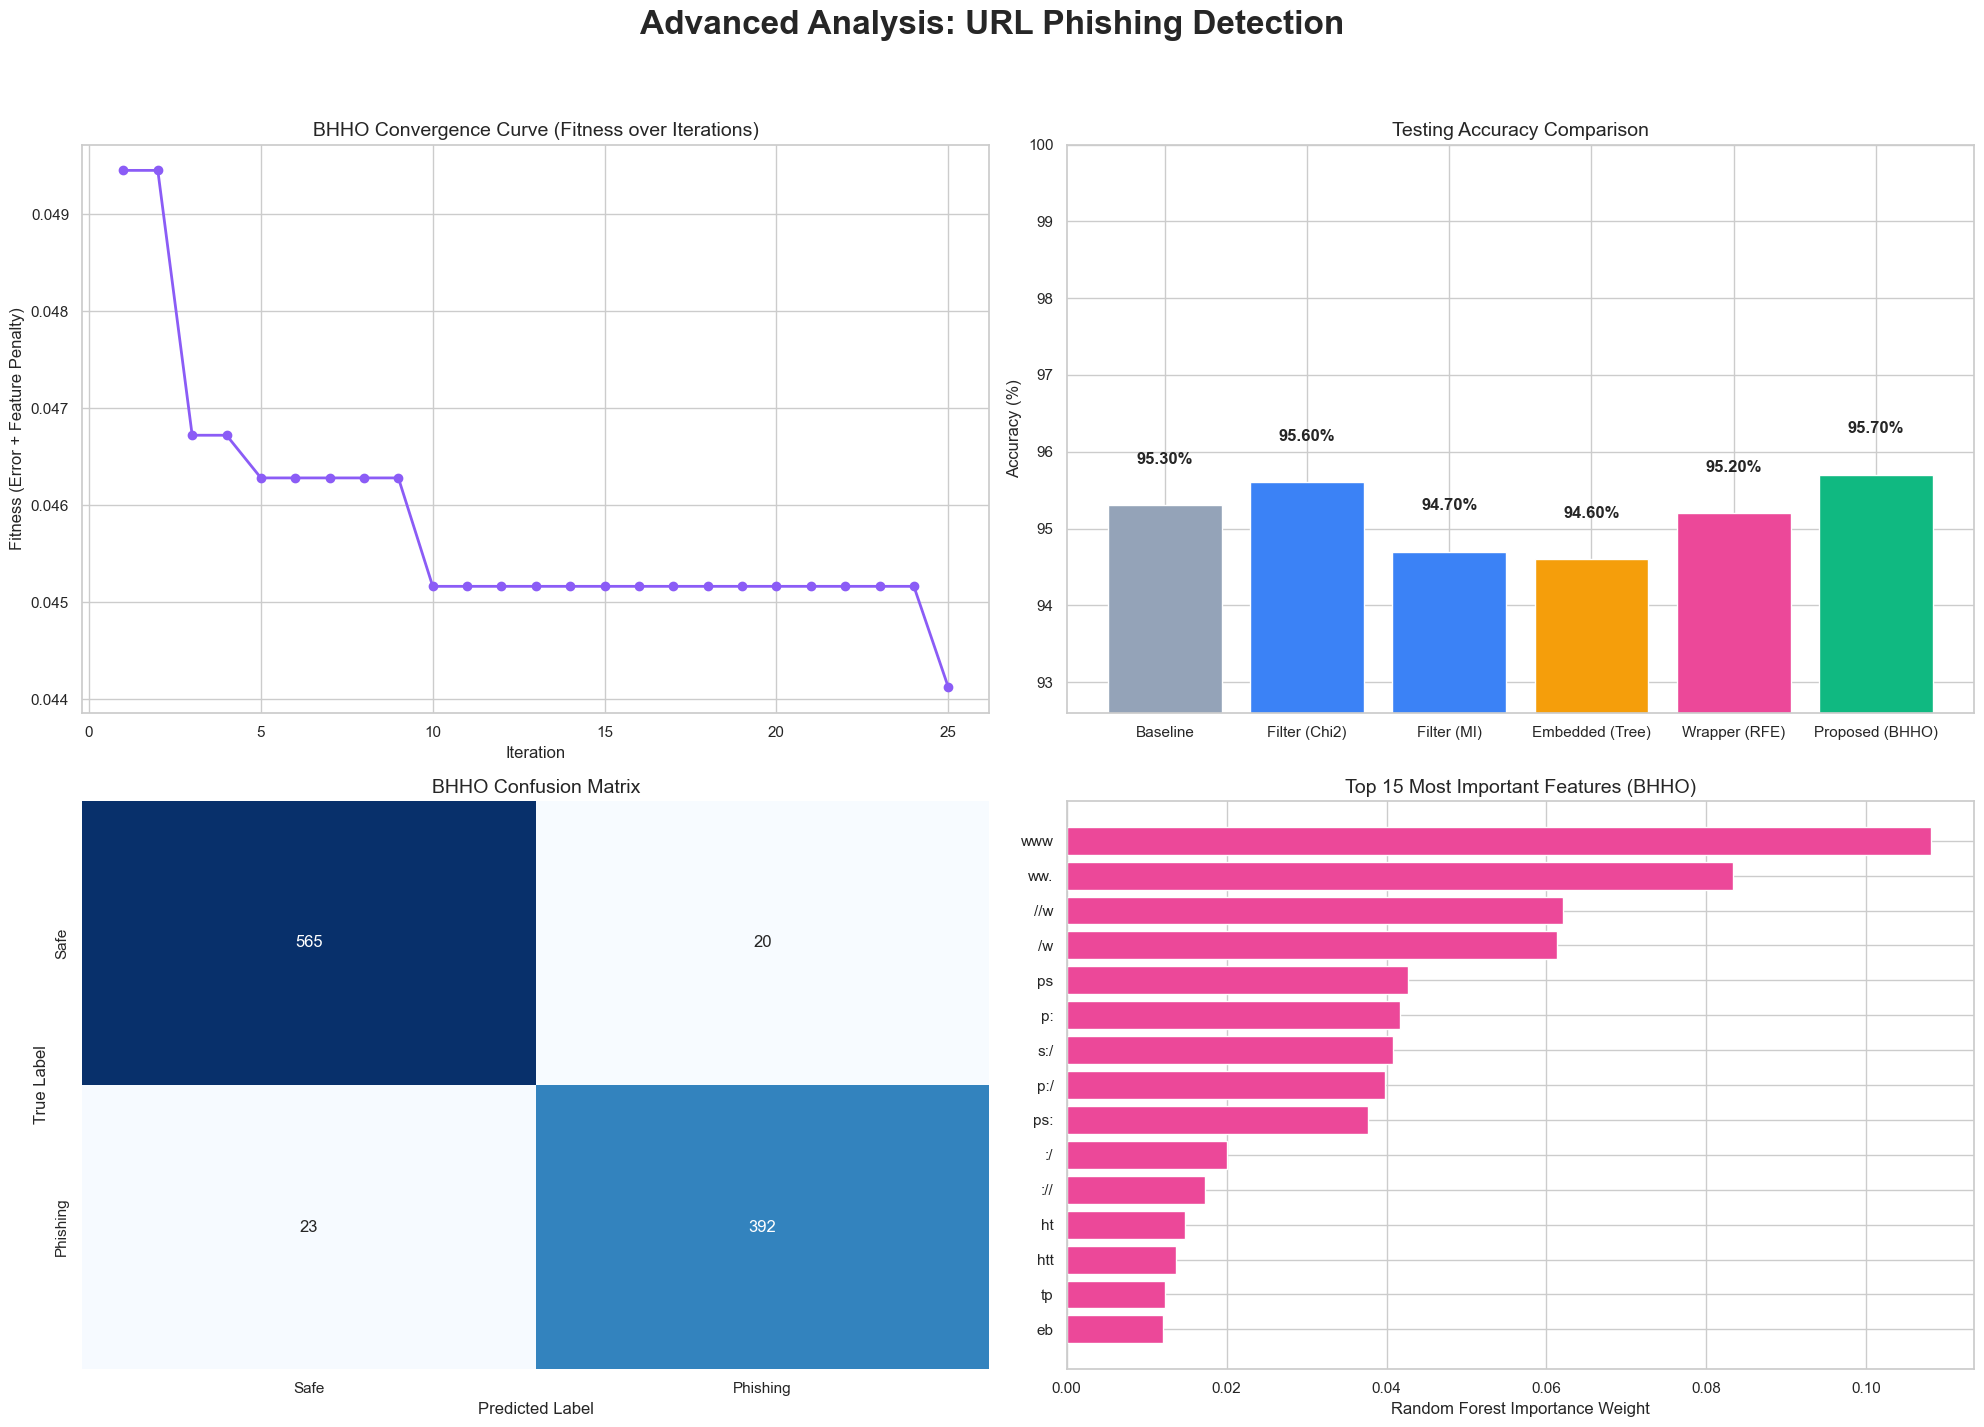

All experiments completed successfully!


In [4]:
print("1. Dataset & Preprocessing...")
url_df1 = pd.read_csv('Phishing URL Detection Kaggle.csv').dropna(subset=['url', 'label'])
url_df2 = pd.read_csv('Phishing URLs.csv').dropna(subset=['url', 'Type'])
url_df2['label'] = url_df2['Type'].apply(lambda x: 1 if str(x).strip().lower() == 'phishing' else 0)
url_df = pd.concat([url_df1[['url', 'label']], url_df2[['url', 'label']]], ignore_index=True)

sample_size = min(5000, len(url_df))
url_df = url_df.sample(n=sample_size, random_state=42)

X_url_text = url_df['url']
y_url = url_df['label']

print("2. Data Splitting...")
X_train_text, X_test_text, y_train, y_test = train_test_split(X_url_text, y_url, test_size=0.2, random_state=42)

print("3. Feature Extraction (TF-IDF)...")
url_vectorizer = TfidfVectorizer(max_features=500, analyzer='char', ngram_range=(2, 3))
X_train_tfidf = url_vectorizer.fit_transform(X_train_text).toarray()
X_test_tfidf = url_vectorizer.transform(X_test_text).toarray()
all_feature_names = url_vectorizer.get_feature_names_out()

print("4. Feature Selection...")
chi2_selector = SelectKBest(chi2, k=250)
X_train_chi2 = chi2_selector.fit_transform(X_train_tfidf, y_train)
X_test_chi2 = chi2_selector.transform(X_test_tfidf)
chi2_features = all_feature_names[chi2_selector.get_support()]

mi_selector = SelectKBest(mutual_info_classif, k=250)
X_train_mi = mi_selector.fit_transform(X_train_tfidf, y_train)
X_test_mi = mi_selector.transform(X_test_tfidf)
mi_features = all_feature_names[mi_selector.get_support()]

embed_selector = SelectFromModel(DecisionTreeClassifier(random_state=42), max_features=250)
X_train_embed = embed_selector.fit_transform(X_train_tfidf, y_train)
X_test_embed = embed_selector.transform(X_test_tfidf)
embed_features = all_feature_names[embed_selector.get_support()]

wrapper_selector = RFE(estimator=DecisionTreeClassifier(random_state=42), n_features_to_select=250, step=50)
X_train_wrapper = wrapper_selector.fit_transform(X_train_tfidf, y_train)
X_test_wrapper = wrapper_selector.transform(X_test_tfidf)
wrapper_features = all_feature_names[wrapper_selector.get_support()]

fitness_func = create_fitness_function(X_train_tfidf, y_train)
optimizer = BHHO(fitness_func, num_agents=20, max_iter=25, dim=X_train_tfidf.shape[1])
bhho_mask, history = optimizer.optimize()
X_train_bhho = X_train_tfidf[:, np.where(bhho_mask == 1)[0]]
X_test_bhho = X_test_tfidf[:, np.where(bhho_mask == 1)[0]]
bhho_features = all_feature_names[np.where(bhho_mask == 1)[0]]

print("5. Performance Measurement & Plotting...")
results = {}
results['Baseline'] = evaluate_model("Baseline (All Features)", X_train_tfidf, X_test_tfidf, y_train, y_test)
results['Filter (Chi2)'] = evaluate_model("Traditional (Chi-Square)", X_train_chi2, X_test_chi2, y_train, y_test, chi2_features)
results['Filter (MI)'] = evaluate_model("Traditional (Mutual Info)", X_train_mi, X_test_mi, y_train, y_test, mi_features)
results['Embedded (Tree)'] = evaluate_model("Embedded (Decision Tree)", X_train_embed, X_test_embed, y_train, y_test, embed_features)
results['Wrapper (RFE)'] = evaluate_model("Traditional Wrapper (RFE)", X_train_wrapper, X_test_wrapper, y_train, y_test, wrapper_features)
results['Proposed (BHHO)'] = evaluate_model("Proposed (BHHO)", X_train_bhho, X_test_bhho, y_train, y_test, bhho_features)

plot_advanced_results("URL Phishing Detection", results, history)

# Save for Web App
joblib.dump(url_vectorizer, 'models/url_vectorizer.pkl')
joblib.dump(bhho_mask, 'models/url_feature_mask.pkl')
joblib.dump(results['Proposed (BHHO)']['model'], 'models/url_model.pkl')
print("All experiments completed successfully!")
